In [3]:
path = '/home/user/Desktop/diploma'

In [4]:
import sys
import sqlite3
import pandas as pd
import re
import torch
import glob
import numpy as np
import json
import os

sys.path.append(os.path.abspath(path+'/results'))
from utils import evaluate_cf, plot_attack_comparison, plot_size_comparison

sys.path.append(os.path.abspath(path+'/eraserbenchmark-master'))
from rationale_benchmark.utils import load_documents, annotations_from_jsonl

# load data

In [5]:
data_root = os.path.join(path, 'eraserbenchmark-master', 'data', 'esnli')
esnli_docs = load_documents(data_root)
esnli = annotations_from_jsonl(os.path.join(data_root, 'test.jsonl'))
esnli[:] = [instance for instance in esnli if instance.classification != 'neutral']

In [16]:
def collect_df(model, path, esnli):
    """
    Collect results for all prompt-engineering variants (including combined ones)
    and store each variant as its own column.
    """

    # Initialize main DataFrame with test-level info
    resDf = pd.DataFrame()
    os.chdir(path + '/eraserbenchmark-master/esnli_dataset_builder/my_dataset')
    resDf['texts'] = pd.read_csv("test.csv")['sentence2']
    resDf['evidences'] = [
        [ev.text
        for ev in next(iter(instance.evidences))
        if '_premise' in ev.docid and ev.docid.endswith('_premise')]
        for instance in esnli
    ]

    resDf['evidence_ranges'] = [
            [(ev.start_token, ev.end_token)
             for ev in next(iter(instance.evidences))
             if '_premise' in ev.docid and ev.docid.endswith('_premise')]
            for instance in esnli
        ]

    base_dir = os.path.join(path, "introspections/results/analysis")
    os.chdir(base_dir)
                           

    # Find all .sqlite result files
    sqlite_files = glob.glob(f'analysis_m-{model}_y-none_d-rte_p-test_t-counterfactual_*.sqlite')

    for file in sqlite_files:
        # Extract everything after c- and before _s-
        variant = file.split("c-")[-1].split("_s-")[0].strip('-')
        if variant == "" or variant == "_":
            variant = "baseline"

        # Normalize spacing and dashes in case of multiple prompt flags
        variant = variant.replace(' ', '-').strip()

        conn = sqlite3.connect(file)
        cursor = conn.cursor()
        cursor.execute("SELECT debug, explain, correct, faithful FROM Counterfactual;")
        df = pd.DataFrame(cursor.fetchall(), columns=['texts', 'selfexp', 'correct', 'faithful'])
        conn.close()

        # Add this variant as its own column
        resDf[variant] = df.apply(
            lambda row: {
                'selfexp': row['selfexp'],
                'correct': row['correct'],
                'faithful': row['faithful']
            },
            axis=1
        )

    # Load attack results
    os.chdir(path)
    csv_files = glob.glob(os.path.join("attacks/esnli_attacks", f"{model}*"))
    for file in csv_files:
        df = pd.read_csv(file)
        attack_name = file.split('_')[-1].replace(".csv", "")
        resDf[attack_name] = df.apply(
            lambda row: {
                'perturbed_text': row['perturbed_text'],
                'result_type': row['result_type'],
                'original_score': row['original_score'],
                'perturbed_score': row['perturbed_score']
            },
            axis=1
        )

    return resDf

In [17]:
models = ['llama3-1b','llama3-3b','llama3-8b','qwen-1b','qwen-3b','qwen-7b']

dataframes = {}

print("Starting data collection...")
for model in models:
    print(f"Collecting data for {model}...")
    df = collect_df(model, path, esnli)
    dataframes[model] = df

print("Data collection complete.")

Starting data collection...
Data collection complete.


In [18]:
def display_instance(df, index=0):
    print(df.head(0))
    row = df.iloc[index]
    print(f"--- Example Instance from df (Index: {index}) ---\n")
    print(f"Original Text:\n{row['texts']}\n")
    print(f"Baseline:\n{row['baseline']['selfexp']}\nCorrect: {row['baseline']['correct']}\tFaithful: {row['baseline']['faithful']}\n")
    print(f"e-persona-you:\n{row['e-persona-you']['selfexp']}\nCorrect: {row['e-persona-you']['correct']}\tFaithful: {row['e-persona-you']['faithful']}\n")
    print(f"e-persona-human:\n{row['e-persona-human']['selfexp']}\nCorrect: {row['e-persona-human']['correct']}\tFaithful: {row['e-persona-human']['faithful']}\n")
    print(f"e-implcit-target:\n{row['e-implcit-target']['selfexp']}\nCorrect: {row['e-implcit-target']['correct']}\tFaithful: {row['e-implcit-target']['faithful']}\n")
    print(f"e-implcit-target-e-persona-you:\n{row['e-implcit-target-e-persona-you']['selfexp']}\nCorrect: {row['e-implcit-target-e-persona-you']['correct']}\tFaithful: {row['e-implcit-target-e-persona-you']['faithful']}\n")
    print(f"e-implcit-target-e-persona-human:\n{row['e-implcit-target-e-persona-human']['selfexp']}\nCorrect: {row['e-implcit-target-e-persona-human']['correct']}\tFaithful: {row['e-implcit-target-e-persona-human']['faithful']}\n")
    print(f"Evidences:{row['evidences']}\nranges:\t{row['evidence_ranges']}\n")
    print(f"TextFooler Adversarial Example:\n{row['TextFoolerJin2019']['perturbed_text']}\n{row['TextFoolerJin2019']['result_type']}")
    print("-"*60)

display_instance(dataframes['llama3-8b'], index=0)

Empty DataFrame
Columns: [texts, evidences, evidence_ranges, e-persona-human, baseline, e-implcit-target-e-persona-human, e-implcit-target, e-implcit-target-e-persona-you, e-persona-you, TextFoolerJin2019]
Index: []
--- Example Instance from df (Index: 0) ---

Original Text:
A man in green pants and blue shirt pushing a cart.

Baseline:
A woman in green pants and blue shirt is smoking a cigarette while pushing a cart.

In this counterfactual explanation, I changed the subject of the sentence from "A man" to "A woman" and added the phrase "is smoking a cigarette" to make the statement entail. This change is minimal, as it only requires changing one word and adding a few words to the original paragraph.
Correct: 1	Faithful: 1.0

e-persona-you:
A woman in green pants and blue shirt is smoking a cigarette while pushing a cart.

In this counterfactual explanation, I changed the subject of the sentence from "A man" to "A woman" to make the statement "A woman is smoking a cigarette" entail fr

# Evaluation

In [ ]:
def evaluate_df(df):
    results = []

    # Identify different types of columns
    base_cols = ['texts', 'evidences', 'evidence_ranges']
    prompt_columns = [col for col in df.columns if col not in base_cols and isinstance(df[col].iloc[0], dict) and 'selfexp' in df[col].iloc[0]]
    attack_columns = [col for col in df.columns if col not in base_cols + prompt_columns]

    device = 'cuda' if TORCH_AVAILABLE and torch.cuda.is_available() else 'cpu'

    # ---- Evaluate counterfactuals for each prompt variant ----
    for index, row in df.iterrows():
        print(index, end="\r", flush=True)
        row_result = {}

        for prompt_col in prompt_columns:
            if row[prompt_col] is not None and 'selfexp' in row[prompt_col]:
                selfexp = row[prompt_col]['selfexp']
                faithfulness = int(row[prompt_col]['faithful']) if not pd.isna(row[prompt_col]['faithful']) else 0
                if selfexp is not None:
                    if faithfulness == 1:
                        row_result[prompt_col] = evaluate_cf(
                            row['texts'],
                            row['evidences'],
                            row['evidence_ranges'],
                            selfexp
                        )
                    else:
                      row_result[prompt_col] = None

        # ---- Evaluate attacks ----
        for attack_col in attack_columns:
            if row[attack_col]['result_type'] == 'Successful':
                attacked_text = row[attack_col]['perturbed_text']
                clean_text = re.sub(r"\[\[(.*?)\]\]", lambda m: m.group(1), attacked_text)
                row_result[attack_col] = evaluate_cf(row['texts'], row['evidences'], row['evidence_ranges'], clean_text)
            else:
                row_result[attack_col] = None
        results.append(row_result)

    # ---- Summaries ----
    summaries = {}

    # Prompt variant success (faithful)
    for prompt_col in prompt_columns:
        total = len(df)
        faithful = sum(
            int(row[prompt_col]['faithful']  if not pd.isna(row[prompt_col]['faithful']) else 0)
            for _, row in df.iterrows()
            if row[prompt_col] is not None and 'faithful' in row[prompt_col]
        )
        summaries[prompt_col] = {'successful': faithful, 'total': total}

    # Attack success rates
    for attack_col in attack_columns:
        successful = 0
        total = 0
        for _, row in df.iterrows():
            total += 1
            if row[attack_col]['result_type'] == 'Successful':
                successful += 1
        summaries[attack_col] = {'successful': successful, 'total': total}

    return pd.DataFrame(results), summaries

In [8]:
os.chdir(path + '/results/esnli_results/results_dataframes')

print("Evaluation started...")

for model in models:
    print(f"Evaluating {model}...")
    df = dataframes[model]
    res, attack_res = evaluate_df(df)

    csv_path = f"{model}_res.csv"
    res.to_csv(csv_path, index=False)

    json_path = f"{model}_attack_res.json"
    with open(json_path, "w") as f:
        json.dump(attack_res, f, indent=4)

    print(f"Finished {model}: saved {csv_path} and {json_path}")

print("All evaluations completed.")

Evaluation started...
Evaluating Llama-3.2-1B-Instruct...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Finished Llama-3.2-1B-Instruct: saved Llama-3.2-1B-Instruct_res.csv and Llama-3.2-1B-Instruct_attack_res.json
Evaluating Llama-3.2-3B-Instruct...
Finished Llama-3.2-3B-Instruct: saved Llama-3.2-3B-Instruct_res.csv and Llama-3.2-3B-Instruct_attack_res.json
Evaluating Meta-Llama-3-8B-Instruct...
Finished Meta-Llama-3-8B-Instruct: saved Meta-Llama-3-8B-Instruct_res.csv and Meta-Llama-3-8B-Instruct_attack_res.json
Evaluating Qwen-1.5B...
Finished Qwen-1.5B: saved Qwen-1.5B_res.csv and Qwen-1.5B_attack_res.json
Evaluating Qwen-3B...
Finished Qwen-3B: saved Qwen-3B_res.csv and Qwen-3B_attack_res.json
Evaluating Qwen-7B...
Finished Qwen-7B: saved Qwen-7B_res.csv and Qwen-7B_attack_res.json
All evaluations completed.


LOAD THE RESULTS

In [9]:
os.chdir(path + '/results/esnli_results/results_dataframes')

# Columns in the DataFrames that contain dicts
dict_columns = [
    'baseline',
    'e-implcit-target-e-persona-human',
    'e-persona-you',
    'e-implcit-target-e-persona-you',
    'e-implcit-target',
    'e-persona-human',
    'TextFoolerJin2019'
]

# Function to safely convert np.float32 to float in a dict
def convert_dict(d):
    if isinstance(d, dict):
        return {k: float(v) if isinstance(v, (np.float32, np.float64)) else v for k, v in d.items()}
    return d

# Function to load a CSV with dict columns
def load_result_csv(csv_path):
    df = pd.read_csv(csv_path)
    for col in dict_columns:
        df[col] = df[col].apply(lambda x: eval(x) if isinstance(x, str) else x)  # eval is okay for trusted files
        df[col] = df[col].apply(convert_dict)
    return df

# Function to load a JSON attack file
def load_attack_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return data

# Example usage
results = {}
attacks = {}

models = ['Llama-3.2-1B-Instruct','Llama-3.2-3B-Instruct','Meta-Llama-3-8B-Instruct','Qwen-1.5B','Qwen-3B','Qwen-7B']

for model in models:
    csv_file = f"{model}_res.csv"
    json_file = f"{model}_attack_res.json"
    results[model] = load_result_csv(csv_file)
    attacks[model] = load_attack_json(json_file)

# Introspection - Attack Evaluation
**Success rate**: the percentage of input instances for which the model was able to generate a faithful counterfactual — a perturbed version of the input that leads the model to predict the opposite label compared to the original classification.

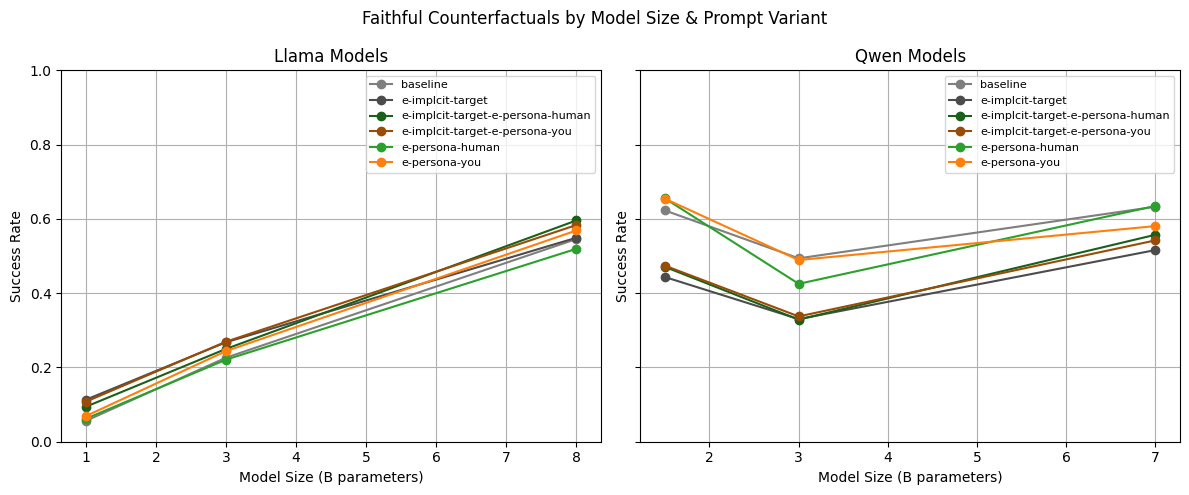

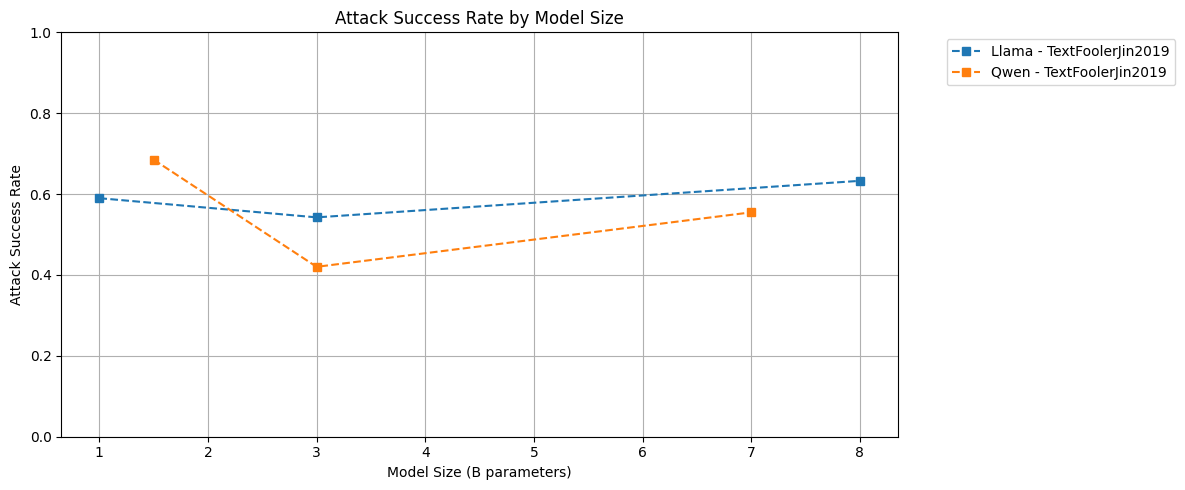

In [10]:
plot_dir = path + '/results/esnli_results/plots'
plot_attack_comparison(models, attacks, plot_dir)

# Counterfactual Evaluation Metrics

Metric groups detected:
  • distance
  • semantic_similarity
  • contradiction
  • evidence_accuracy
  • evidence_precision
  • evidence_recall
  • evidence_f1

🔹 Processing metric group: distance
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/distance_Introspection_llama.png


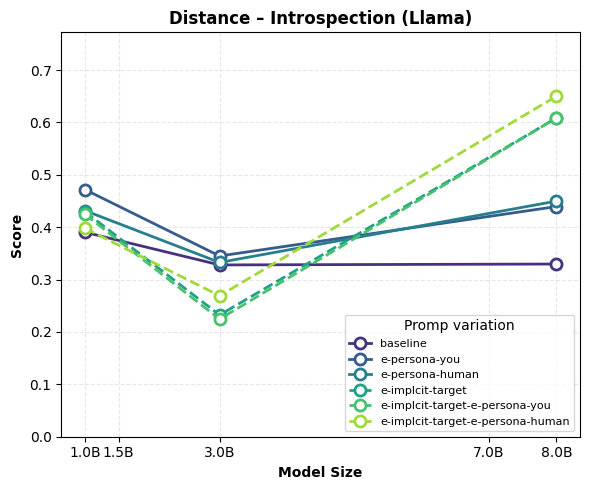

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/distance_Introspection_qwen.png


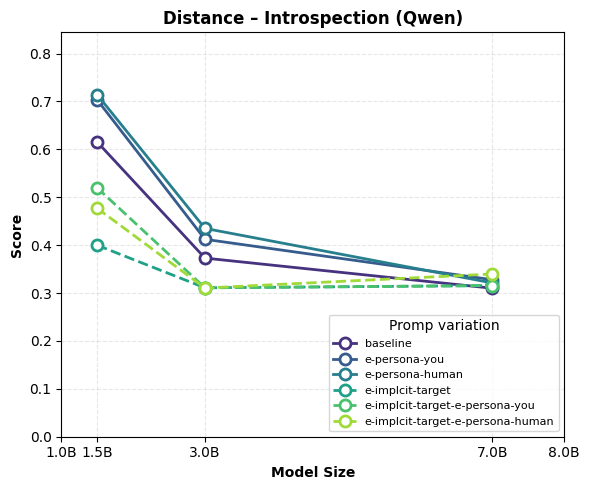

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/distance_TextFooler.png


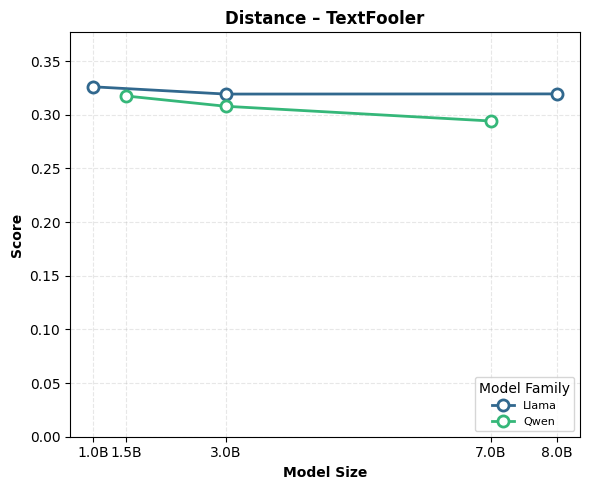


🔹 Processing metric group: semantic_similarity
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/semantic_similarity_Introspection_llama.png


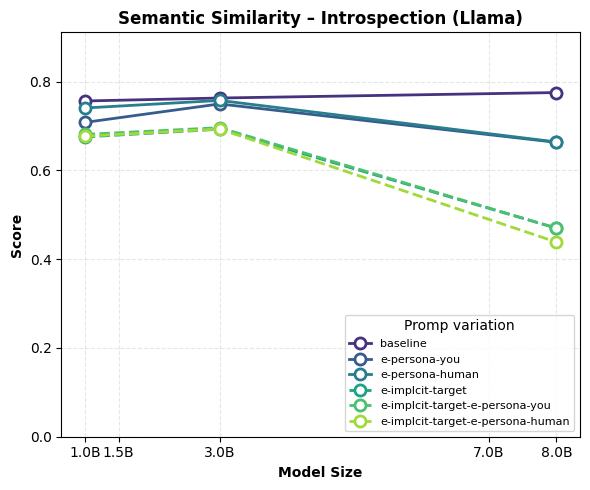

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/semantic_similarity_Introspection_qwen.png


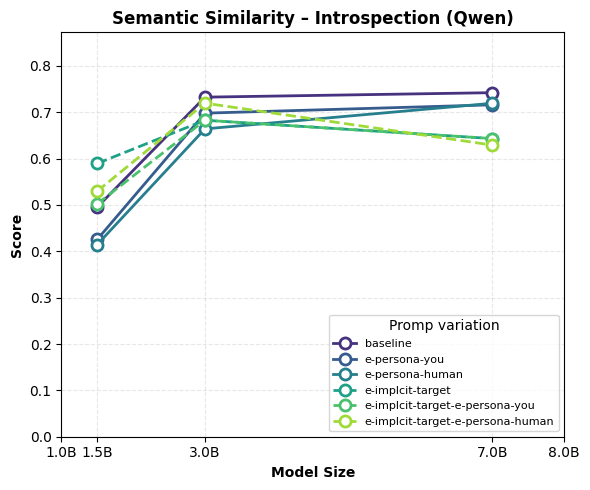

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/semantic_similarity_TextFooler.png


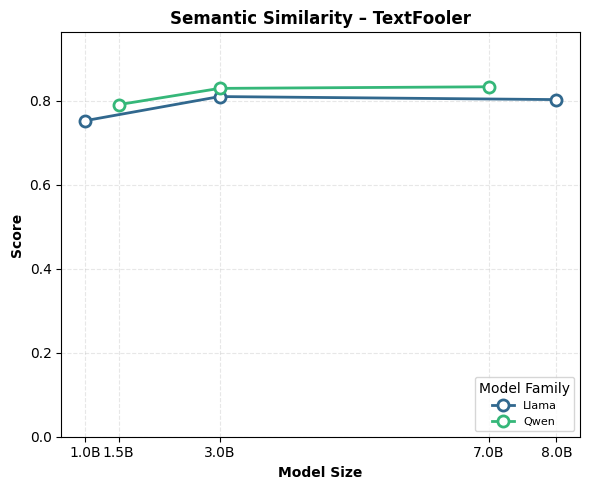


🔹 Processing metric group: contradiction
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/contradiction_Introspection_llama.png


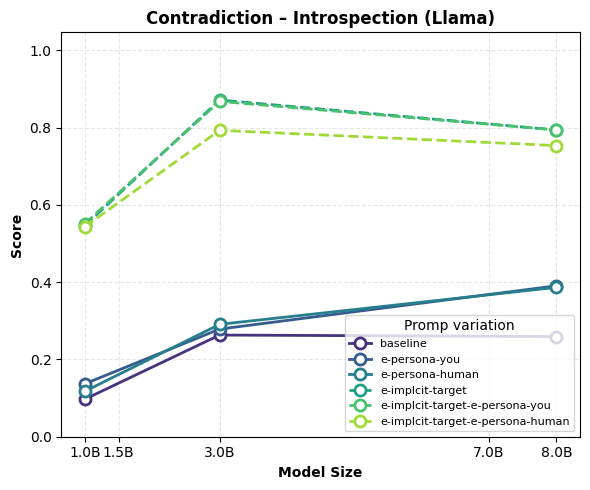

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/contradiction_Introspection_qwen.png


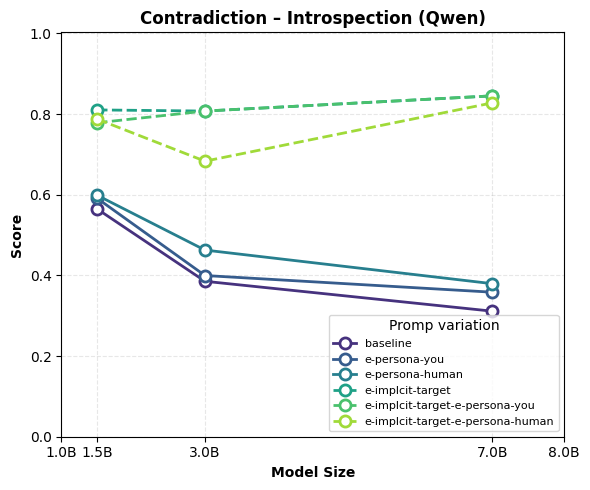

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/contradiction_TextFooler.png


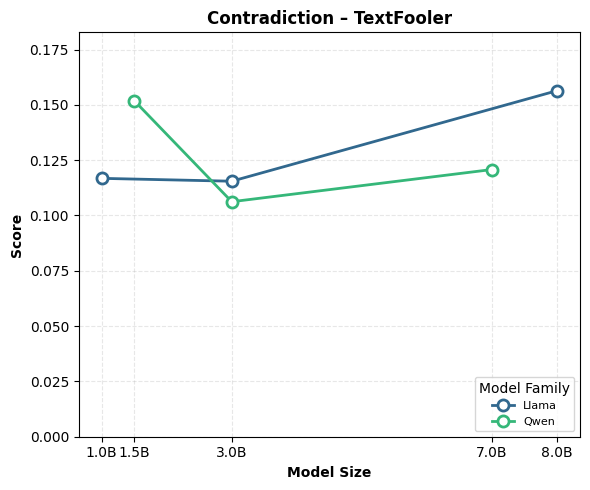


🔹 Processing metric group: evidence_accuracy
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_accuracy_Introspection_llama.png


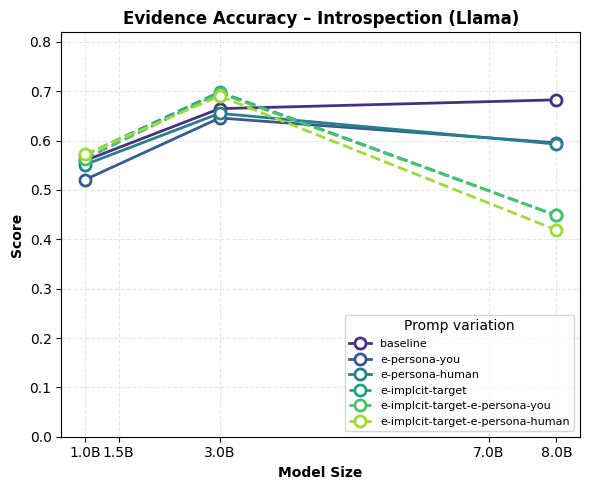

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_accuracy_Introspection_qwen.png


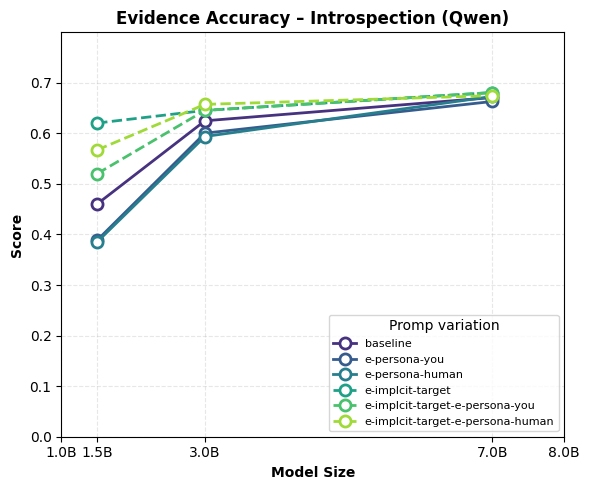

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_accuracy_TextFooler.png


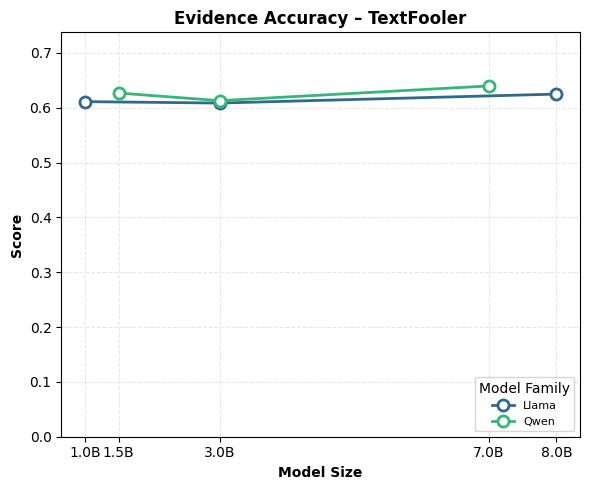


🔹 Processing metric group: evidence_precision
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_precision_Introspection_llama.png


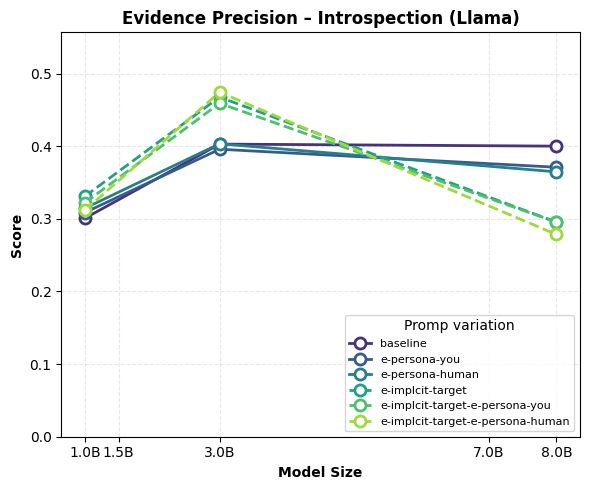

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_precision_Introspection_qwen.png


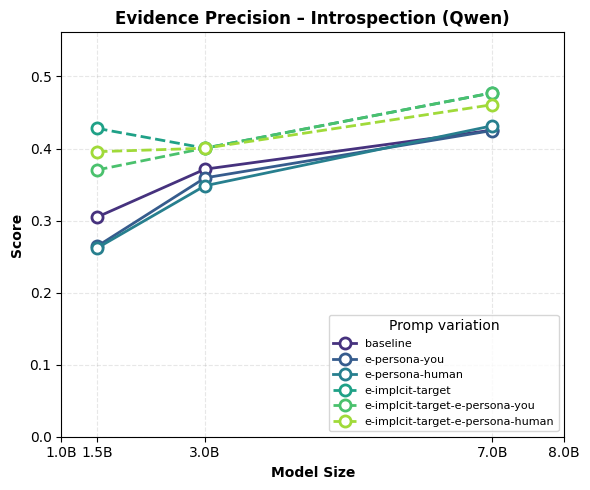

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_precision_TextFooler.png


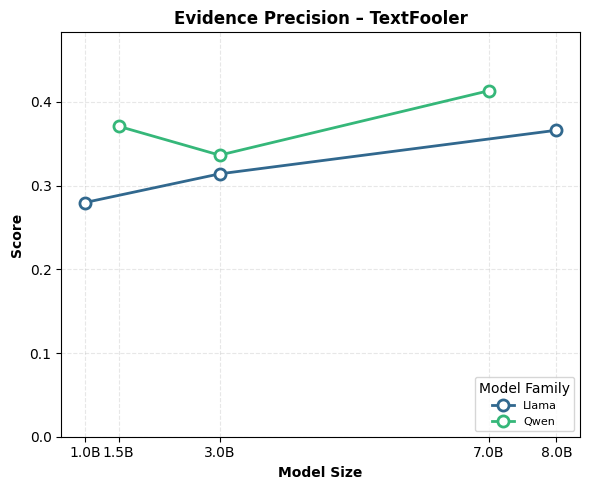


🔹 Processing metric group: evidence_recall
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_recall_Introspection_llama.png


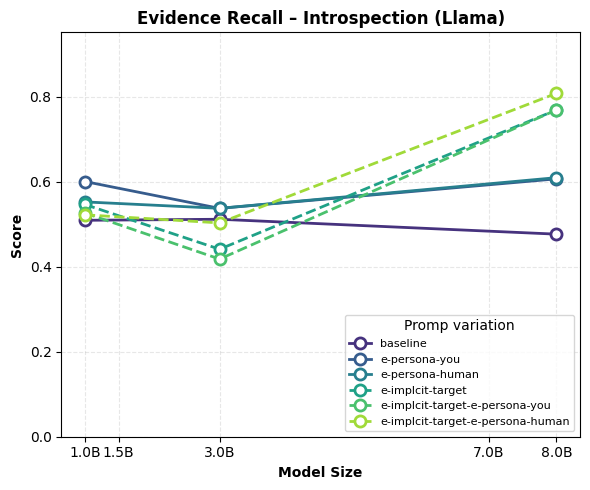

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_recall_Introspection_qwen.png


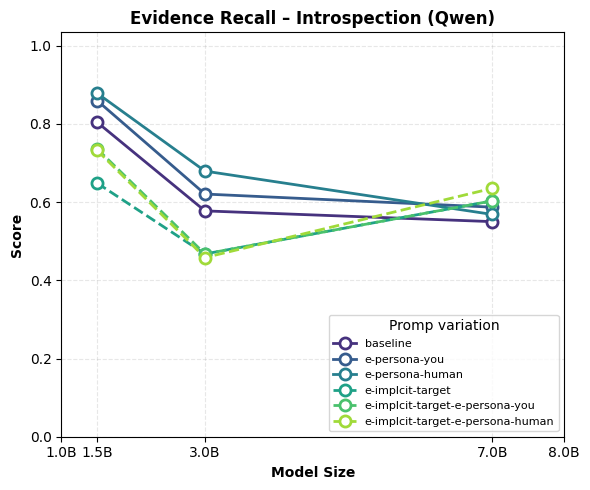

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_recall_TextFooler.png


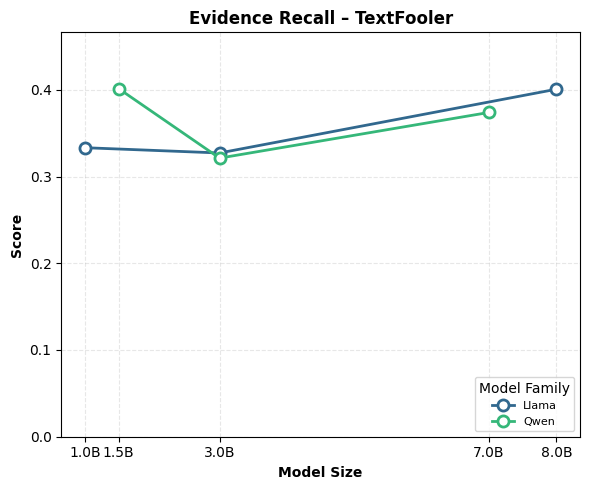


🔹 Processing metric group: evidence_f1
   📊 Plotting Introspection for llama
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_f1_Introspection_llama.png


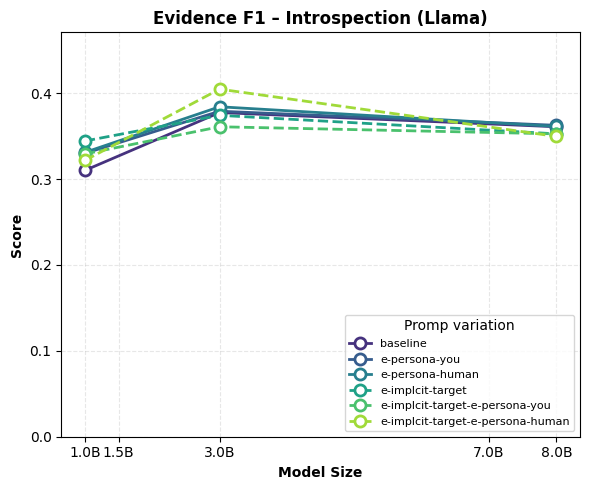

   📊 Plotting Introspection for qwen
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_f1_Introspection_qwen.png


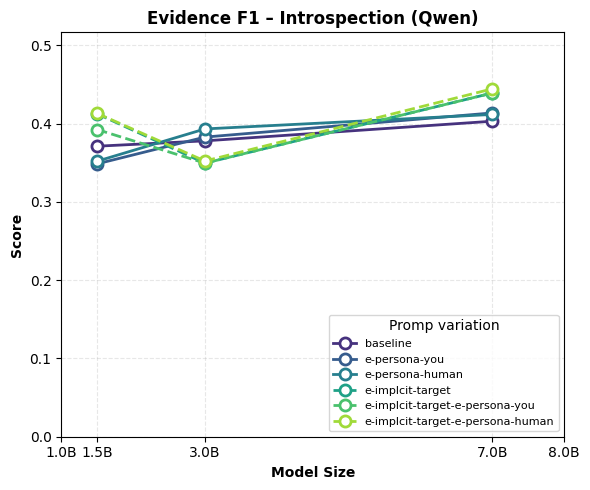

   📊 Plotting TextFooler (both families combined)
   ✅ Saved /content/drive/MyDrive/thesis/code/results/esnli_results/plots/evidence_f1_TextFooler.png


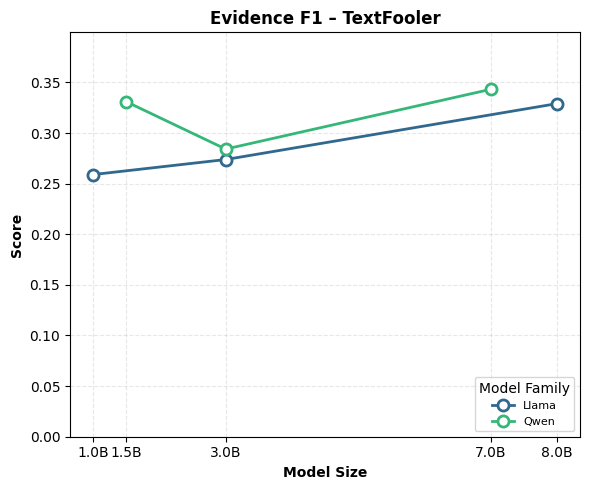

In [11]:
directory = path+'/results/esnli_results/plots'
plot_size_comparison(models, results, directory, "viridis")